In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install /content/drive/MyDrive/Thesis/Projects/Banksy_py/.

In [ ]:
!pip install "pybanksy[notebooks]"

In [1]:
import os
import sys
os.chdir("/content/drive/MyDrive/Thesis/Projects/Steamboat_X/examples_Banksy")
cwd = os.getcwd()
print(cwd)

sys.path.append("../")

/content/drive/MyDrive/Thesis/Projects/Steamboat_X/examples_Banksy


In [2]:
import scanpy as sc
import numpy as np
from banksy.main import median_dist_to_nearest_neighbour
from banksy.initialize_banksy import initialize_banksy
from banksy.run_banksy import run_banksy_multiparam
from banksy.embed_banksy import generate_banksy_matrix

In [3]:
# Load you sc.read_h5ad("your_data.h5ad")
adata = sc.read_h5ad("../../Data/Mouse_Coronal_Embeddings/Xenium_Morpho_integrated.h5ad")
adata.obsm['p_Morpho_Embedding'] = 1 + adata.obsm['Morpho_Embedding'] ## Shift the morpho features to make them positive

In [4]:
adata.obs['xcoord'] = adata.obsm['spatial'][:, 0]
adata.obs['ycoord'] = adata.obsm['spatial'][:, 1]

In [5]:
coord_keys = ('xcoord', 'ycoord', 'spatial')

# set params
# ==========
plot_graph_weights = True
k_geom = 8
max_m = 1
nbr_weight_decay = "scaled_gaussian" # can also be "reciprocal", "uniform" or "ranked"

# Find median distance to closest neighbours, the median distance will be `sigma`
nbrs = median_dist_to_nearest_neighbour(adata, key = coord_keys[2])


Median distance to closest cell = 9.527377849172183

---- Ran median_dist_to_nearest_neighbour in 0.16 s ----




Median distance to closest cell = 9.527377849172183

---- Ran median_dist_to_nearest_neighbour in 0.16 s ----

---- Ran generate_spatial_distance_graph in 0.26 s ----

---- Ran row_normalize in 0.24 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 1.82 s ----

---- Ran generate_spatial_distance_graph in 0.42 s ----

---- Ran theta_from_spatial_graph in 0.60 s ----

---- Ran row_normalize in 0.21 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 2.73 s ----

----- Plotting Weights Graph -----
Maximum weight: 0.3436999884986646

---- Ran plot_graph_weights in 5.00 s ----

Maximum weight: (0.17281339151498365-0.02577475353705989j)

---- Ran plot_graph_weights in 9.65 s ----



/usr/local/lib/python3.12/dist-packages/matplotlib/collections.py:430: ComplexWarning: Casting complex values to real discards the imaginary part
  renderer.draw_path_collection(


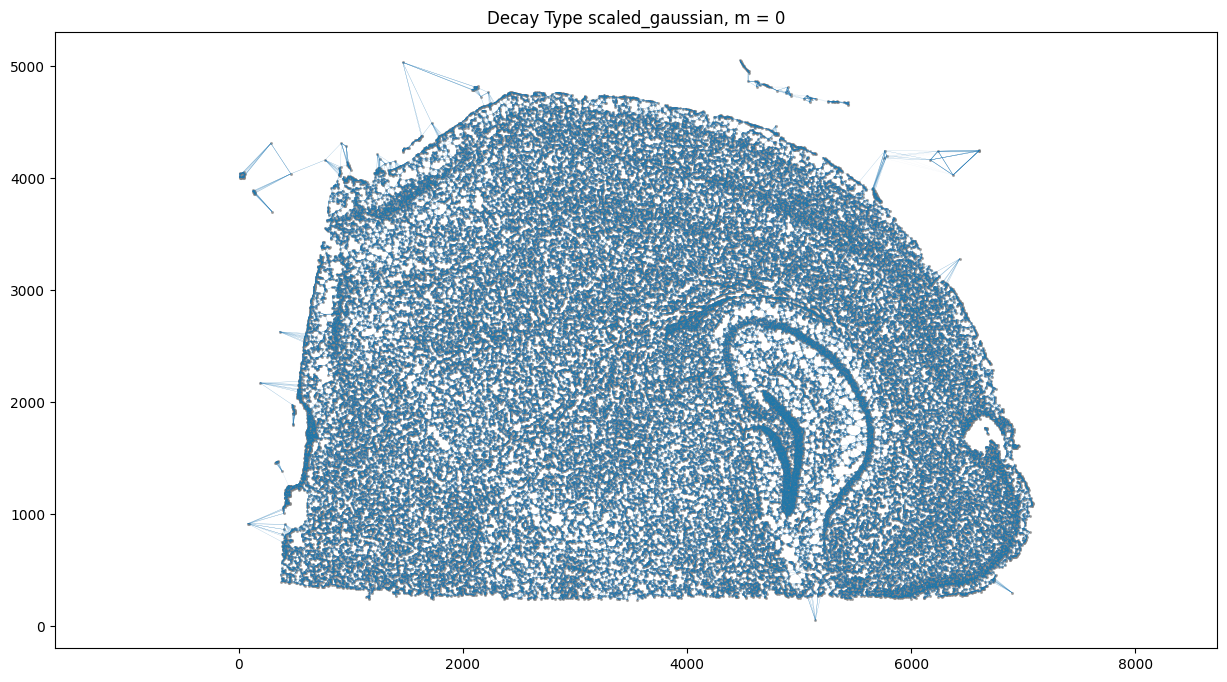

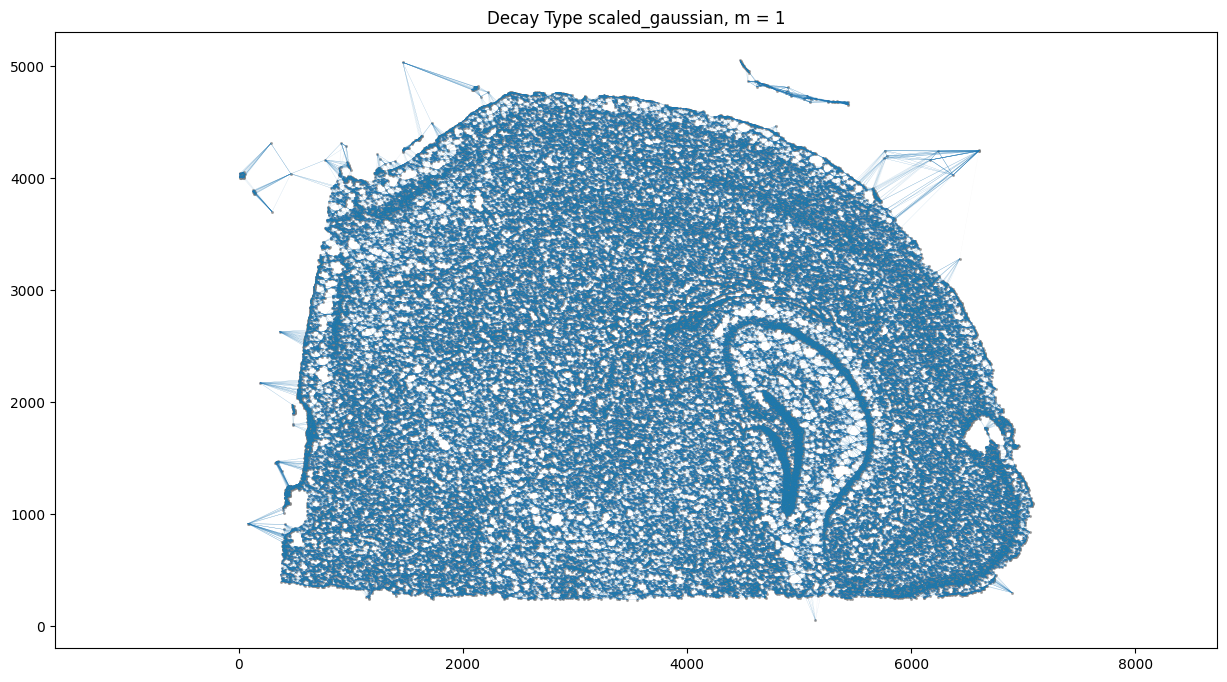

In [6]:
# Initialize BANKSY
# lambda_list: weights for spatial vs non-spatial (0 = no spatial, 1 = full spatial)
banksy_dict = initialize_banksy(
    adata,
    coord_keys,
    k_geom,  # number of neighbors for spatial graph
    nbr_weight_decay=nbr_weight_decay,
    max_m=max_m,
    plt_edge_hist=False,
    plt_nbr_weights=True,
    plt_agf_angles=False,
    plt_theta=False,
)

In [7]:
# The following are the main hyperparameters for BANKSY
resolutions = [0.7] # clustering resolution for UMAP
pca_dims = [20] # Dimensionality in which PCA reduces to
lambda_list = [0.2, 0.5, 0.7, 0.8] # list of lambda parameters

banksy_dict, banksy_matrix = generate_banksy_matrix(adata, banksy_dict, lambda_list, max_m)

Runtime Nov-30-2025-17-08

5006 genes to be analysed:
Gene List:
Index(['A1cf', 'A2m', 'Aatf', 'Abca1', 'Abca13', 'Abca3', 'Abca4', 'Abca7',
       'Abca8a', 'Abca8b',
       ...
       'Zp1', 'Zp3', 'Zscan2', 'Zscan21', 'Zswim5', 'Zswim9', 'Zup1', 'Zyx',
       'Zzef1', 'a'],
      dtype='object', length=5006)

Check if X contains only finite (non-NAN) values
Decay Type: scaled_gaussian
Weights Object: {'weights': {0: <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 505384 stored elements and shape (63173, 63173)>, 1: <Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 1010768 stored elements and shape (63173, 63173)>}}

Nbr matrix | Mean: 0.27 | Std: 0.77
Size of Nbr | Shape: (63173, 5006)
Top 3 entries of Nbr Mat:

[[0.         0.         0.15794465]
 [0.         0.         0.2127455 ]
 [0.         0.         0.06309036]]

AGF matrix | Mean: 0.12 | Std: 0.29
Size of AGF mat (m = 1) | Shape: (63173, 5006)
Top entries of AGF:
[[0.         0.         0.1290265

In [8]:
from banksy.main import concatenate_all

banksy_dict["nonspatial"] = {
    # Here we simply append the nonspatial matrix (adata.X) to obtain the nonspatial clustering results
    0.0: {"adata": concatenate_all([adata.X], 0, adata=adata), }
}

print(banksy_dict['nonspatial'][0.0]['adata'])

Scale factors squared: [1.]
Scale factors: [1.]
AnnData object with n_obs × n_vars = 63173 × 5006
    obs: 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'xcoord', 'ycoord'
    var: 'gene_ids', 'feature_types', 'genome', 'is_nbr', 'k'


In [9]:
from banksy_utils.umap_pca import pca_umap

pca_umap(banksy_dict,
         pca_dims = pca_dims,
         add_umap = True,
         plt_remaining_var = False,
         )

Current decay types: ['scaled_gaussian', 'nonspatial']

Reducing dims of dataset in (Index = scaled_gaussian, lambda = 0.2)

Setting the total number of PC = 20
Original shape of matrix: (63173, 15018)
Reduced shape of matrix: (63173, 20)
------------------------------------------------------------
min_value = -278.3431117447944, mean = -4.340662190881197e-16, max = 414.54188619333803

Conducting UMAP and adding embeddings to adata.obsm["reduced_pc_20_umap"]
UMAP embedding
------------------------------------------------------------
shape: (63173, 2)


AxisArrays with keys: reduced_pc_20, reduced_pc_20_umap

Reducing dims of dataset in (Index = scaled_gaussian, lambda = 0.5)

Setting the total number of PC = 20
Original shape of matrix: (63173, 15018)
Reduced shape of matrix: (63173, 20)
------------------------------------------------------------
min_value = -117.30214774722681, mean = 3.144820554960569e-16, max = 330.62937203149073

Conducting UMAP and adding embeddings to adata.obsm

In [10]:
import random
# Note that BANKSY itself is deterministic, here the seeds affect the umap clusters and leiden partition
seed = 1234
np.random.seed(seed)
random.seed(seed)

In [11]:
from banksy.cluster_methods import run_Leiden_partition

results_df, max_num_labels = run_Leiden_partition(
    banksy_dict,
    resolutions,
    num_nn = 50,
    num_iterations = -1,
    partition_seed = seed,
    match_labels = True,
)

Decay type: scaled_gaussian
Neighbourhood Contribution (Lambda Parameter): 0.2
reduced_pc_20 

reduced_pc_20_umap 

PCA dims to analyse: [20]

Setting up partitioner for (nbr decay = scaled_gaussian), Neighbourhood contribution = 0.2, PCA dimensions = 20)



/usr/local/lib/python3.12/dist-packages/banksy/cluster_methods.py:350: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  for key in adata_temp.obsm_keys():



Nearest-neighbour weighted graph (dtype: float64, shape: (63173, 63173)) has 3158650 nonzero entries.
---- Ran find_nn in 50.40 s ----


Nearest-neighbour connectivity graph (dtype: int16, shape: (63173, 63173)) has 3158650 nonzero entries.

(after computing shared NN)
Allowing nearest neighbours only reduced the number of shared NN from 32492515 to 3156048.


Shared nearest-neighbour (connections only) graph (dtype: int16, shape: (63173, 63173)) has 3100742 nonzero entries.

Shared nearest-neighbour (number of shared neighbours as weights) graph (dtype: int16, shape: (63173, 63173)) has 3100742 nonzero entries.

sNN graph data:
[39 31 38 ... 10  5  7]

---- Ran shared_nn in 2.72 s ----


-- Multiplying sNN connectivity by weights --


shared NN with distance-based weights graph (dtype: float64, shape: (63173, 63173)) has 3100742 nonzero entries.
shared NN weighted graph data: [0.02755087 0.02780872 0.02789943 ... 0.17054662 0.17853216 0.22326484]

Converting graph (dtype: float64, sh

/usr/local/lib/python3.12/dist-packages/banksy/cluster_methods.py:350: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  for key in adata_temp.obsm_keys():



Nearest-neighbour weighted graph (dtype: float64, shape: (63173, 63173)) has 3158650 nonzero entries.
---- Ran find_nn in 75.51 s ----


Nearest-neighbour connectivity graph (dtype: int16, shape: (63173, 63173)) has 3158650 nonzero entries.

(after computing shared NN)
Allowing nearest neighbours only reduced the number of shared NN from 41430895 to 3155520.


Shared nearest-neighbour (connections only) graph (dtype: int16, shape: (63173, 63173)) has 3057184 nonzero entries.

Shared nearest-neighbour (number of shared neighbours as weights) graph (dtype: int16, shape: (63173, 63173)) has 3057184 nonzero entries.

sNN graph data:
[42 27 22 ... 14 10 14]

---- Ran shared_nn in 2.93 s ----


-- Multiplying sNN connectivity by weights --


shared NN with distance-based weights graph (dtype: float64, shape: (63173, 63173)) has 3057184 nonzero entries.
shared NN weighted graph data: [0.02764723 0.02778901 0.0279081  ... 0.1402194  0.14513937 0.14721191]

Converting graph (dtype: float64, sh

...


Nearest-neighbour weighted graph (dtype: float64, shape: (63173, 63173)) has 3158650 nonzero entries.
---- Ran find_nn in 70.57 s ----


Nearest-neighbour connectivity graph (dtype: int16, shape: (63173, 63173)) has 3158650 nonzero entries.

(after computing shared NN)
Allowing nearest neighbours only reduced the number of shared NN from 43051413 to 3156503.


Shared nearest-neighbour (connections only) graph (dtype: int16, shape: (63173, 63173)) has 3061973 nonzero entries.

Shared nearest-neighbour (number of shared neighbours as weights) graph (dtype: int16, shape: (63173, 63173)) has 3061973 nonzero entries.

sNN graph data:
[40 20 31 ... 22 20  7]

---- Ran shared_nn in 2.74 s ----


-- Multiplying sNN connectivity by weights --


shared NN with distance-based weights graph (dtype: float64, shape: (63173, 63173)) has 3061973 nonzero entries.
shared NN weighted graph data: [0.02130451 0.02161655 0.02176853 ... 0.16830804 0.16861243 0.20120963]

Converting graph (dtype: float64, sh

/usr/local/lib/python3.12/dist-packages/banksy/cluster_methods.py:350: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  for key in adata_temp.obsm_keys():



Nearest-neighbour weighted graph (dtype: float64, shape: (63173, 63173)) has 3158650 nonzero entries.
---- Ran find_nn in 36.69 s ----


Nearest-neighbour connectivity graph (dtype: int16, shape: (63173, 63173)) has 3158650 nonzero entries.

(after computing shared NN)
Allowing nearest neighbours only reduced the number of shared NN from 31111563 to 3156438.


Shared nearest-neighbour (connections only) graph (dtype: int16, shape: (63173, 63173)) has 3103580 nonzero entries.

Shared nearest-neighbour (number of shared neighbours as weights) graph (dtype: int16, shape: (63173, 63173)) has 3103580 nonzero entries.

sNN graph data:
[38 40 45 ...  5  6  7]

---- Ran shared_nn in 3.02 s ----


-- Multiplying sNN connectivity by weights --


shared NN with distance-based weights graph (dtype: float64, shape: (63173, 63173)) has 3103580 nonzero entries.
shared NN weighted graph data: [0.03407514 0.03492927 0.03514136 ... 0.24470917 0.2483257  0.25104718]

Converting graph (dtype: float64, sh

/usr/local/lib/python3.12/dist-packages/banksy/labels.py:398: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  expand_labels(label_list[sort_indices[0]],
/usr/local/lib/python3.12/dist-packages/banksy/labels.py:414: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  current_label = label_list[index]


,decay,lambda_param,num_pcs,resolution,num_labels,labels,adata,relabeled
nonspatial_pc20_nc0.00_r0.70,nonspatial,0.0,20,0.7,22,"Label object:\nNumber of labels: 22, number of...",[[[View of AnnData object with n_obs × n_vars ...,"Label object:\nNumber of labels: 22, number of..."
scaled_gaussian_pc20_nc0.20_r0.70,scaled_gaussian,0.2,20,0.7,17,"Label object:\nNumber of labels: 17, number of...",[[[View of AnnData object with n_obs × n_vars ...,"Label object:\nNumber of labels: 17, number of..."
scaled_gaussian_pc20_nc0.50_r0.70,scaled_gaussian,0.5,20,0.7,17,"Label object:\nNumber of labels: 17, number of...",[[[View of AnnData object with n_obs × n_vars ...,"Label object:\nNumber of labels: 17, number of..."
scaled_gaussian_pc20_nc0.70_r0.70,scaled_gaussian,0.7,20,0.7,16,"Label object:\nNumber of labels: 16, number of...",[[[View of AnnData object with n_obs × n_vars ...,"Label object:\nNumber of labels: 16, number of..."
scaled_gaussian_pc20_nc0.80_r0.70,scaled_gaussian,0.8,20,0.7,14,"Label object:\nNumber of labels: 14, number of...",[[[View of AnnData object with n_obs × n_vars ...,"Label object:\nNumber of labels: 14, number of..."


In [12]:
from banksy.plot_banksy import plot_results

c_map =  'tab20' # specify color map
weights_graph =  banksy_dict['scaled_gaussian']['weights'][0]

plot_results(
    results_df,
    weights_graph,
    c_map,
    match_labels = True,
    coord_keys = coord_keys,
    max_num_labels  =  max_num_labels,
    save_path = os.path.join(cwd, 'tmp_png'),
    save_fig = True, # save the spatial map of all clusters
    save_seperate_fig = True, # save the figure of all clusters plotted seperately
)

Output hidden; open in https://colab.research.google.com to view.